### ML regression model 

In [1]:
import pandas as pd 

In [2]:
df = pd.read_excel("data/Microsoft_LinkedIn_Processed.xlsx", parse_dates=['Date'], index_col=0)
df

,Close,High,Low,Open,Volume,change_tomorrow,change_tomorrow_direction
Date,,,,,,,
2016-12-08,55.079998,55.594599,54.926523,55.341812,21220800,1.549152,UP
2016-12-09,55.946697,55.964754,55.188343,55.233482,27349400,0.321693,UP
2016-12-12,56.127254,56.244620,55.720996,55.811275,20198100,1.286142,UP
2016-12-13,56.858536,57.255768,56.190463,56.425191,35718900,-0.478626,DOWN
2016-12-14,56.587692,57.282851,56.452270,56.876589,30352700,-0.159799,DOWN
...,...,...,...,...,...,...,...
2025-05-16,454.269989,454.359985,448.730011,452.049988,23849800,1.002464,UP
2025-05-19,458.869995,459.589996,450.799988,450.880005,21336500,-0.152778,DOWN
2025-05-20,458.170013,458.339996,454.320007,455.589996,15441800,-1.237379,DOWN


In [3]:
target = df.change_tomorrow 
explanatory = df[['Close','High', 'Low', 'Open', 'Volume']]

In [4]:
from sklearn.tree import DecisionTreeRegressor 

model_dtr = DecisionTreeRegressor(max_depth=15)

In [5]:
model_dtr.fit(X=explanatory, y=target)

DecisionTreeRegressor(max_depth=15)

[Text(0.8982309867831542, 0.96875, 'Volume <= 92951148.0\nsquared_error = 3.046\nsamples = 2125\nvalue = 0.084'),
 Text(0.8547057011648745, 0.90625, 'Volume <= 91578148.0\nsquared_error = 2.95\nsamples = 2121\nvalue = 0.076'),
 Text(0.8764683439740144, 0.9375, 'True  '),
 Text(0.8511214717741935, 0.84375, 'Volume <= 87003952.0\nsquared_error = 2.809\nsamples = 2120\nvalue = 0.084'),
 Text(0.7676551299283154, 0.78125, 'Volume <= 78979100.0\nsquared_error = 2.784\nsamples = 2118\nvalue = 0.08'),
 Text(0.6114751344086021, 0.71875, 'Volume <= 78726700.0\nsquared_error = 2.768\nsamples = 2109\nvalue = 0.088'),
 Text(0.6078909050179212, 0.65625, 'Volume <= 46526000.0\nsquared_error = 2.737\nsamples = 2108\nvalue = 0.084'),
 Text(0.4350918458781362, 0.59375, 'Volume <= 35868700.0\nsquared_error = 2.417\nsamples = 1974\nvalue = 0.108'),
 Text(0.2853942652329749, 0.53125, 'Volume <= 33468450.0\nsquared_error = 2.058\nsamples = 1782\nvalue = 0.056'),
 Text(0.20239695340501793, 0.46875, 'Open <= 

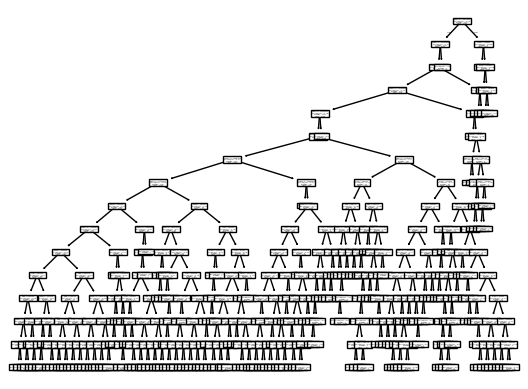

In [6]:
from sklearn.tree import plot_tree

plot_tree(decision_tree=model_dtr, feature_names=model_dtr.feature_names_in_)

In [7]:
y_pred = model_dtr.predict(X=explanatory)

In [8]:
df_predictions = df[['change_tomorrow']].copy()

df_predictions['prediction'] = y_pred 
df_predictions

,change_tomorrow,prediction
Date,,
2016-12-08,1.549152,0.120742
2016-12-09,0.321693,0.562616
2016-12-12,1.286142,0.120742
2016-12-13,-0.478626,-0.199914
2016-12-14,-0.159799,0.147998
...,...,...
2025-05-16,1.002464,-0.503013
2025-05-19,-0.152778,-0.503013
2025-05-20,-1.237379,-0.503013


In [9]:
model_dtr.score(X=explanatory, y=target)

0.42499468045531774

### Calc error of regression model

In [10]:
df_predictions['error'] = df_predictions.prediction - df_predictions.change_tomorrow

In [11]:
df_predictions

,change_tomorrow,prediction,error
Date,,,
2016-12-08,1.549152,0.120742,-1.428410
2016-12-09,0.321693,0.562616,0.240923
2016-12-12,1.286142,0.120742,-1.165400
2016-12-13,-0.478626,-0.199914,0.278713
2016-12-14,-0.159799,0.147998,0.307798
...,...,...,...
2025-05-16,1.002464,-0.503013,-1.505477
2025-05-19,-0.152778,-0.503013,-0.350235
2025-05-20,-1.237379,-0.503013,0.734366


In [12]:
#aggregrate all the errors 
df_predictions.error.sum()

np.float64(8.526512829121202e-14)

In [13]:
df_predictions.error.abs()

Date
2016-12-08    1.428410
2016-12-09    0.240923
2016-12-12    1.165400
2016-12-13    0.278713
2016-12-14    0.307798
                ...   
2025-05-16    1.505477
2025-05-19    0.350235
2025-05-20    0.734366
2025-05-21    1.006460
2025-05-22    0.536569
Name: error, Length: 2125, dtype: float64

In [14]:
df_predictions['sqaured_error'] = df_predictions.error ** 2

In [15]:
#now aggregrate sqaured errors 
sum_of_sqaured_errors = df_predictions.sqaured_error.sum()

In [16]:
#mean sqaured error
mse =df_predictions.sqaured_error.mean()

In [17]:
mse

np.float64(1.7513408404331623)

In [18]:
#coounter the fact of sqauring the error by calc root mse
import numpy as np 

rmse = np.sqrt(mse)
rmse #can be intepreted as the std 
#for any prediction, subtract the actual value, calc the sum of quares, 
#div by total to get mse, and then sqrt to get rmse 
#thf std = 1.32, thf for any pedcition the model does, 
# 68% will fall in the range of +-1.3% of the inc of the stock tomorrow 


np.float64(1.3233823485422354)

<Axes: >

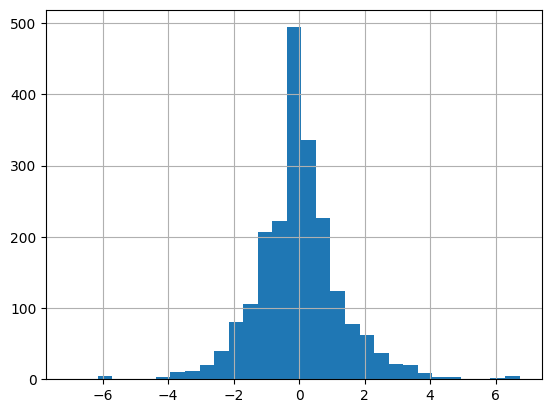

In [19]:
df_predictions.error.hist(bins=31)

In [20]:
#2 std = 95% CI 
rmse * 2

np.float64(2.6467646970844707)

In [21]:
import pickle 

In [22]:
with open('models/model_dtr_regression.pkl', 'wb') as f: 
    pickle.dump(model_dtr, f)

### Bakctesting with reg model 

In [24]:
with open('models/model_dtr_regression.pkl', 'rb') as f:
    model_dtr = pickle.load(f)

In [25]:
model_dtr

DecisionTreeRegressor(max_depth=15)

In [26]:
df

,Close,High,Low,Open,Volume,change_tomorrow,change_tomorrow_direction
Date,,,,,,,
2016-12-08,55.079998,55.594599,54.926523,55.341812,21220800,1.549152,UP
2016-12-09,55.946697,55.964754,55.188343,55.233482,27349400,0.321693,UP
2016-12-12,56.127254,56.244620,55.720996,55.811275,20198100,1.286142,UP
2016-12-13,56.858536,57.255768,56.190463,56.425191,35718900,-0.478626,DOWN
2016-12-14,56.587692,57.282851,56.452270,56.876589,30352700,-0.159799,DOWN
...,...,...,...,...,...,...,...
2025-05-16,454.269989,454.359985,448.730011,452.049988,23849800,1.002464,UP
2025-05-19,458.869995,459.589996,450.799988,450.880005,21336500,-0.152778,DOWN
2025-05-20,458.170013,458.339996,454.320007,455.589996,15441800,-1.237379,DOWN


In [28]:
from backtesting import Backtest, Strategy 

In [ ]:
class Regression(Strategy):

    def init(self):
        self.model = model_dtr
        self.already_bought = False

    def next(self):
        explanatory_today = self.data.df.iloc[[-1], :] 
        forecast_tomorrow = model_dtr.predict(explanatory_today)[0] 

        #improve stratgy to get higher equity via changign the numbers here or using the bt optimisation method
        if forecast_tomorrow > 5 and self.already_bought == False: #5% inc 
            self.buy() 
            self.already_bought = True 
        elif forecast_tomorrow < -5 and self.already_bought== True: #5% dec
            self.sell() 
            self.already_bought = False
        else: 
            pass
            

In [30]:
df

,Close,High,Low,Open,Volume,change_tomorrow,change_tomorrow_direction
Date,,,,,,,
2016-12-08,55.079998,55.594599,54.926523,55.341812,21220800,1.549152,UP
2016-12-09,55.946697,55.964754,55.188343,55.233482,27349400,0.321693,UP
2016-12-12,56.127254,56.244620,55.720996,55.811275,20198100,1.286142,UP
2016-12-13,56.858536,57.255768,56.190463,56.425191,35718900,-0.478626,DOWN
2016-12-14,56.587692,57.282851,56.452270,56.876589,30352700,-0.159799,DOWN
...,...,...,...,...,...,...,...
2025-05-16,454.269989,454.359985,448.730011,452.049988,23849800,1.002464,UP
2025-05-19,458.869995,459.589996,450.799988,450.880005,21336500,-0.152778,DOWN
2025-05-20,458.170013,458.339996,454.320007,455.589996,15441800,-1.237379,DOWN


In [33]:
df_explanatory = df.drop(columns=['change_tomorrow',	'change_tomorrow_direction'])

In [35]:
bt = Backtest(df_explanatory, Regression, cash=10000, commission=.002, exclusive_orders=True)

In [36]:
results = bt.run()

In [37]:
results.to_frame(name='Values').loc[:'Return [%]']

,Values
Start,2016-12-08 00:00:00
End,2025-05-22 00:00:00
Duration,3087 days 00:00:00
Exposure Time [%],76.329412
Equity Final [$],26123.028278
Equity Peak [$],27059.837957
Commissions [$],949.94761
Return [%],161.230283


In [38]:
bt.plot(filename='backtest_report.html')
#4 charts in this order: equity, profit and loss, trades, volume
#buggest fall from a peak = max draw down - equity graph 
#max draw down period = how long it takes to get bakc to a peak within an obsv period - equity grpah 
#profit/loss graph = can see the highhest profits and los 


GridPlot(id='p1329', ...)